<a href="https://colab.research.google.com/github/chrisldz/ECON3916-33674-Statistical-Machine-Learning/blob/main/Assignment%204/Econ_3916_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
pip install missingno category_encoders -q

In [18]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import missingno as msno
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.eval_measures import rmse

In [19]:
clinical = pd.read_csv("OmniCare_Clinical_Vitals.csv")
telemetry = pd.read_csv("OmniCare_Telemetry_Data.csv")

clinical.head()
telemetry.head()

,Patient_ID,High_Deductible_Insurance_Plan,Inpatient_Admission_Rate,Continuous_Heart_Rate,Primary_Diagnosis_Code,Clinic_Capacity_Percentage,Time_of_Day_Index,Procedure_Cost_USD
0,1000,1,0.341,76.9,J86.381,0.63,19.4,1635.84
1,1001,0,0.213,79.6,M29.789,0.71,19.3,1355.77
2,1002,0,0.166,92.3,E49.618,0.76,16.8,1189.19
3,1003,1,0.143,79.3,E66.244,0.52,11.5,1250.93
4,1004,0,0.219,75.9,J45.553,0.65,20.2,1986.34


DAG Explanation

The positive relationship between inpatient admission rate and high deductible insurance plan is probably not a true causal effect.

A likely omitted confounder is patient income or socioeconomic status. Lower-income patients may be more likely to enroll in high deductible plans, and they may also have worse baseline health, which increases inpatient admissions.

Because this hidden factor affects both variables, the observed correlation is likely biased. If we regress admission rate on insurance type without controlling for this confounder, the estimated effect will suffer from omitted variable bias.

In [20]:
X_vif = clinical[['Weight_kg', 'Height_cm', 'BMI', 'Systolic_BP', 'Diastolic_BP']].copy()

X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]

print("Initial VIF:")
print(vif_data)

Initial VIF:
        Feature          VIF
0         const  3369.565806
1     Weight_kg    57.428058
2     Height_cm    28.419446
3           BMI    16.981232
4   Systolic_BP     4.219406
5  Diastolic_BP     4.219820


In [21]:
X_vif_reduced = clinical[['Weight_kg', 'Height_cm', 'Systolic_BP', 'Diastolic_BP']].copy()
X_vif_reduced_const = sm.add_constant(X_vif_reduced)

vif_data_reduced = pd.DataFrame()
vif_data_reduced["Feature"] = X_vif_reduced_const.columns
vif_data_reduced["VIF"] = [variance_inflation_factor(X_vif_reduced_const.values, i) for i in range(X_vif_reduced_const.shape[1])]

print("\nVIF after dropping BMI:")
print(vif_data_reduced)


VIF after dropping BMI:
        Feature         VIF
0         const  321.090128
1     Weight_kg    3.763969
2     Height_cm    3.763812
3   Systolic_BP    4.219406
4  Diastolic_BP    4.219820


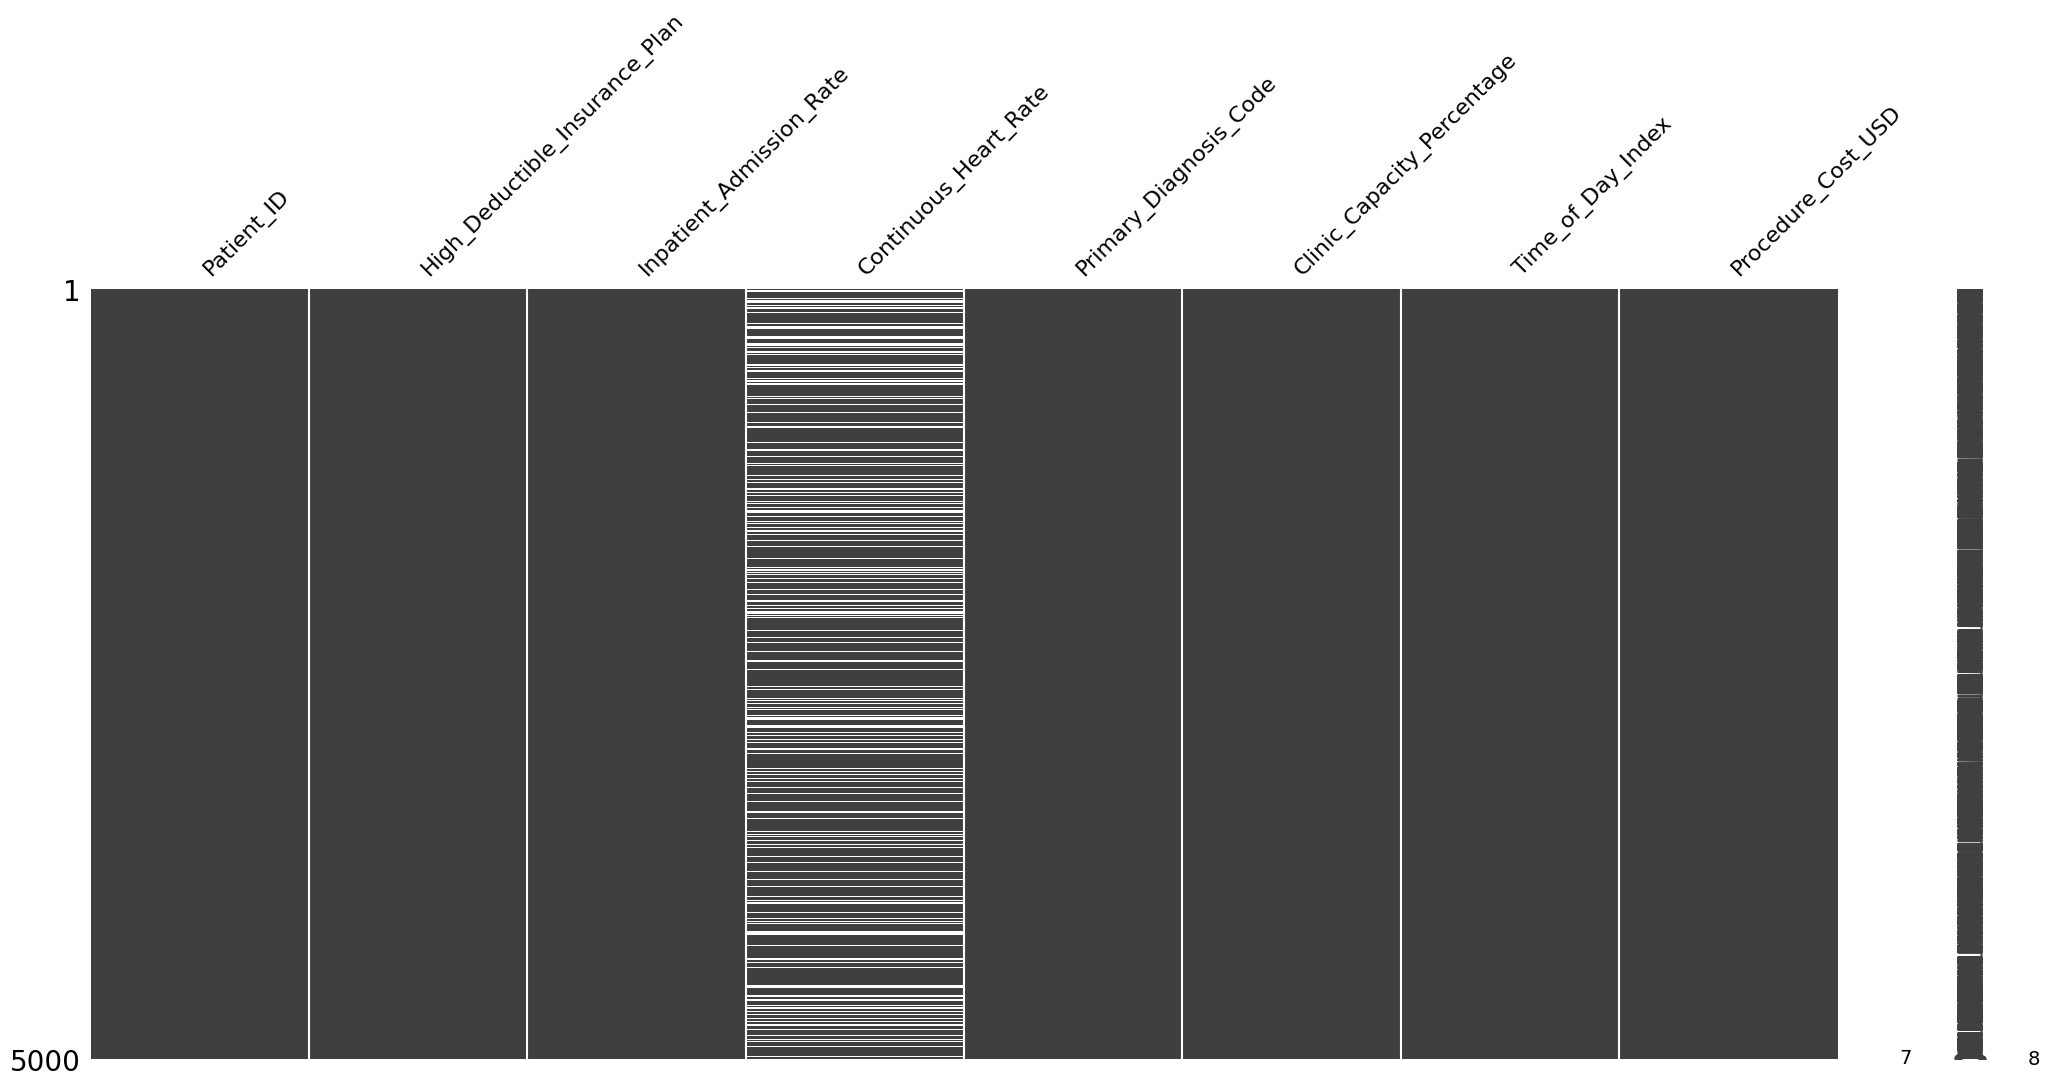

Patient_ID                           0
High_Deductible_Insurance_Plan       0
Inpatient_Admission_Rate             0
Continuous_Heart_Rate             1214
Primary_Diagnosis_Code               0
Clinic_Capacity_Percentage           0
Time_of_Day_Index                    0
Procedure_Cost_USD                   0
dtype: int64


In [22]:
msno.matrix(telemetry)
plt.show()

print(telemetry.isnull().sum())

The missing values in `Continuous_Heart_Rate` are more consistent with MNAR.

The reason is that missingness may depend on an unobserved factor such as patient income. If lower-income patients are less able to continuously transmit telemetry data, then the missingness is related to the patient condition itself, not just random chance.

Because of this, simple mean imputation would damage the data structure and reduce useful variation.

Dummy Variable Trap

If we create dummy variables for all diagnosis categories and also include a constant term, the design matrix becomes perfectly collinear.

This happens because the sum of all dummy columns is always equal to 1, which duplicates the intercept. As a result, OLS cannot uniquely estimate all coefficients.

To avoid this problem, one category must be dropped and used as the reference group.

In [23]:
encoder = ce.TargetEncoder(cols=['Primary_Diagnosis_Code'])

telemetry['Target_Encoded_Diagnosis'] = encoder.fit_transform(
    telemetry['Primary_Diagnosis_Code'],
    telemetry['Procedure_Cost_USD']
)

telemetry[['Primary_Diagnosis_Code', 'Target_Encoded_Diagnosis']].head()

,Primary_Diagnosis_Code,Target_Encoded_Diagnosis
0,J86.381,1707.697108
1,M29.789,1792.303198
2,E49.618,1730.334968
3,E66.244,1725.060944
4,J45.553,1801.821085


In [24]:
df = pd.merge(telemetry, clinical, on='Patient_ID', how='inner')

In [25]:
df['Continuous_Heart_Rate'] = df['Continuous_Heart_Rate'].fillna(df['Continuous_Heart_Rate'].median())

In [26]:
formula = '''
Procedure_Cost_USD ~ Target_Encoded_Diagnosis
+ Clinic_Capacity_Percentage
+ Time_of_Day_Index
+ Continuous_Heart_Rate
+ Weight_kg
+ Height_cm
+ Systolic_BP
+ Diastolic_BP
'''

model = smf.ols(formula=formula, data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     200.5
Date:                Thu, 26 Mar 2026   Prob (F-statistic):          3.61e-295
Time:                        12:20:53   Log-Likelihood:                -36161.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4991   BIC:                         7.240e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [27]:
y_pred = model.predict(df)
model_rmse = rmse(df['Procedure_Cost_USD'], y_pred)

print(f"RMSE: ${model_rmse:,.2f}")

RMSE: $334.73


RMSE measures the average prediction error in dollar terms.

If a typical MRI costs around $1,200 and the RMSE is large, then the algorithm can make pricing errors that are financially meaningful. This creates operational risk, possible overcharging or undercharging, and also legal or regulatory risk in a hospital setting.

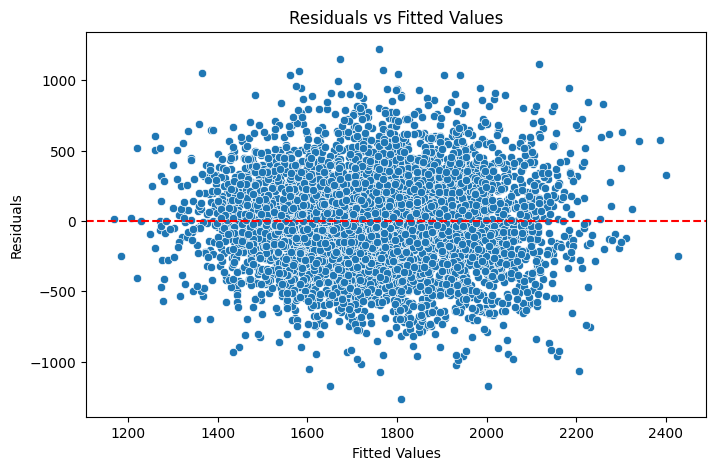

In [28]:
residuals = df['Procedure_Cost_USD'] - y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

If the residuals spread out more at higher fitted values, this suggests heteroskedasticity.

That means the model becomes less stable for expensive procedures. In practice, this is dangerous because the largest pricing errors may happen exactly in the highest-cost cases.

In [29]:
from statsmodels.stats.diagnostic import het_white

# residuals
residuals = model.resid

# independent variables
exog = model.model.exog

# White test
white_test = het_white(residuals, exog)

lm_stat = white_test[0]
lm_pvalue = white_test[1]
f_stat = white_test[2]
f_pvalue = white_test[3]

print("White Test Results:")
print(f"LM Statistic: {lm_stat}")
print(f"LM p-value: {lm_pvalue}")
print(f"F Statistic: {f_stat}")
print(f"F p-value: {f_pvalue}")

White Test Results:
LM Statistic: 198.37420830945362
LM p-value: 1.74855794111685e-21
F Statistic: 4.65251602845539
F p-value: 5.185949847393158e-22


The p-value is extremely small (much smaller than 0.05), so we reject the null hypothesis of homoskedasticity.

This means there is strong evidence of heteroskedasticity in the model. The variance of the errors is not constant.

In practice, this suggests that the model may be less reliable, especially for certain ranges of predicted values. It also means that standard OLS standard errors may not be valid, which can affect statistical inference.